In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from scipy.ndimage import gaussian_filter
import json

np.random.seed(1)
plt.rcParams['figure.dpi'] = 110

WAVELENGTH_UM = 0.532
MAG = 2.0
CAM_PIXEL_UM = 2.5
EFF_PIXEL_UM = CAM_PIXEL_UM / MAG
N_LR = 128
DS = 4
N_HR = N_LR * DS
HR_PIXEL_UM = EFF_PIXEL_UM / DS
Z_RANGE_UM = 50.0
Z_STEPS = 161
Z_ARRAY_UM = np.linspace(-Z_RANGE_UM, Z_RANGE_UM, Z_STEPS)
CAMERA_NYQUIST = 1 / (2 * EFF_PIXEL_UM)

def make_objects(N):
    img_amp = transform.resize(data.camera(), (N, N), anti_aliasing=True)
    img_amp = img_amp / np.max(img_amp)
    img_phase_raw = transform.resize(data.moon(), (N, N), anti_aliasing=True)
    img_phase_smooth = gaussian_filter(img_phase_raw, sigma=4)
    img_phase_smooth = img_phase_smooth / np.max(img_phase_smooth)
    return {
        "Pure Amplitude": img_amp * np.exp(1j * np.zeros_like(img_amp)),
        "Weak Phase (smooth)": np.ones((N, N)) * np.exp(1j * (img_phase_smooth * 0.05)),
        "Strong Phase (smooth)": np.ones((N, N)) * np.exp(1j * (img_phase_smooth * 1.5)),
    }

objects_hr = make_objects(N_HR)

def brenner_raw(image):
    return np.sum((image[2:, :] - image[:-2, :]) ** 2)

def build_grid(N_lr, N_hr, eff_pixel):
    hr_pixel = eff_pixel * (N_lr / N_hr)  # keep object plane FOV fixed: N_hr*hr_pixel == N_lr*eff_pixel
    fx = np.fft.fftshift(np.fft.fftfreq(N_lr, d=eff_pixel))
    FX, FY = np.meshgrid(fx, fx)
    return FX, FY

FX_LR, FY_LR = build_grid(N_LR, N_HR, EFF_PIXEL_UM)
cy, cx = N_HR // 2, N_HR // 2
ys, ye = cy - N_LR // 2, cy + N_LR // 2
xs, xe = cx - N_LR // 2, cx + N_LR // 2

def propagate_stack(obj_fourier_full, NA):
    O_crop = obj_fourier_full[ys:ye, xs:xe]
    pupil = (np.sqrt(FX_LR**2 + FY_LR**2) <= NA / WAVELENGTH_UM).astype(float)
    radicand = np.maximum((1.0 / WAVELENGTH_UM) ** 2 - FX_LR**2 - FY_LR**2, 0.0)
    kz = 2 * np.pi * np.sqrt(radicand)
    stack = np.empty((len(Z_ARRAY_UM), N_LR, N_LR))
    for i, z in enumerate(Z_ARRAY_UM):
        pupil_z = pupil * np.exp(1j * z * kz)
        E_f = O_crop * pupil_z
        E_s = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_f)))
        stack[i] = np.abs(E_s) ** 2
    return stack

print("Setup complete. Running extended experiments...")

Setup complete. Running extended experiments...


## Experiment 1 — Fine NA sweep: locating the exact critical NA

Sweep NA in fine steps and track the sign of the curve's concavity at focus (BCI). The critical
NA is where BCI crosses zero -- i.e., where the true minimum turns into a false peak.

Critical NA (weak phase, minimum->peak transition):   None
Critical NA (strong phase, minimum->peak transition): None
Camera Nyquist frequency = 0.400 1/um  |  Optical cutoff = NA/wavelength
NA at which optical cutoff EQUALS camera Nyquist: NA = 0.213


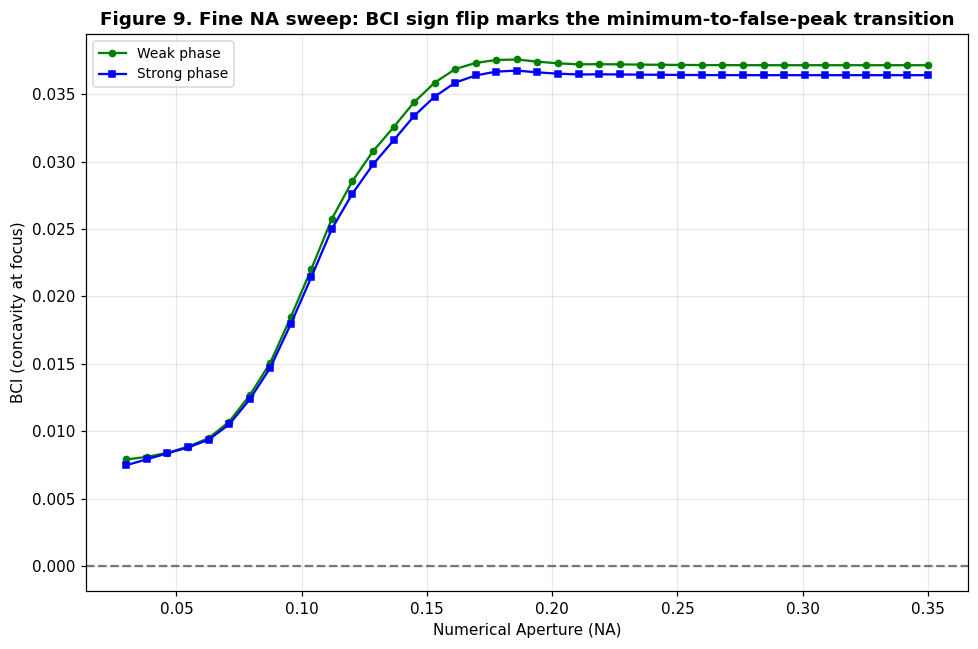

In [2]:
NA_fine = np.linspace(0.03, 0.35, 40)

def extract_bci(curve):
    c_idx = len(curve) // 2
    step = max(len(curve) // 32, 1)
    return (curve[c_idx - step] + curve[c_idx + step] - 2 * curve[c_idx])

bci_weak, bci_strong = [], []
O_fourier_weak = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(objects_hr["Weak Phase (smooth)"])))
O_fourier_strong = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(objects_hr["Strong Phase (smooth)"])))

for NA in NA_fine:
    stack_w = propagate_stack(O_fourier_weak, NA)
    scores_w = np.array([brenner_raw(f) for f in stack_w])
    norm_w = (scores_w - scores_w.min()) / (scores_w.max() - scores_w.min() + 1e-8)
    bci_weak.append(extract_bci(norm_w))

    stack_s = propagate_stack(O_fourier_strong, NA)
    scores_s = np.array([brenner_raw(f) for f in stack_s])
    norm_s = (scores_s - scores_s.min()) / (scores_s.max() - scores_s.min() + 1e-8)
    bci_strong.append(extract_bci(norm_s))

bci_weak = np.array(bci_weak); bci_strong = np.array(bci_strong)

def find_crossing(na_arr, bci_arr):
    sign_change = np.where(np.diff(np.sign(bci_arr)) != 0)[0]
    if len(sign_change) == 0:
        return None
    i = sign_change[0]
    # linear interpolation for the zero crossing
    na0, na1 = na_arr[i], na_arr[i+1]
    b0, b1 = bci_arr[i], bci_arr[i+1]
    return na0 + (0 - b0) * (na1 - na0) / (b1 - b0)

crit_weak = find_crossing(NA_fine, bci_weak)
crit_strong = find_crossing(NA_fine, bci_strong)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(NA_fine, bci_weak, 'o-', color='green', label='Weak phase', markersize=4)
ax.plot(NA_fine, bci_strong, 's-', color='blue', label='Strong phase', markersize=4)
ax.axhline(0, color='k', ls='--', alpha=0.5)
if crit_weak: ax.axvline(crit_weak, color='green', ls=':', alpha=0.7, label=f'Weak critical NA = {crit_weak:.3f}')
if crit_strong: ax.axvline(crit_strong, color='blue', ls=':', alpha=0.7, label=f'Strong critical NA = {crit_strong:.3f}')
ax.set_xlabel("Numerical Aperture (NA)"); ax.set_ylabel("BCI (concavity at focus)")
ax.set_title("Figure 9. Fine NA sweep: BCI sign flip marks the minimum-to-false-peak transition", fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/fig9_fine_na_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Critical NA (weak phase, minimum->peak transition):   {crit_weak}")
print(f"Critical NA (strong phase, minimum->peak transition): {crit_strong}")
print(f"Camera Nyquist frequency = {CAMERA_NYQUIST:.3f} 1/um  |  Optical cutoff = NA/wavelength")
print(f"NA at which optical cutoff EQUALS camera Nyquist: NA = {CAMERA_NYQUIST*WAVELENGTH_UM:.3f}")

## Experiment 2 — Quantified convergence (replacing the "eyeball it" check)

Use `ds=16` as the reference ("ground truth") simulation and compute the RMS deviation of the
Brenner curve at lower `ds` values from that reference, for the borderline NA=0.25 strong-phase
case. This turns Figure 6 from a qualitative impression into an actual convergence curve.

RMS deviation from ds=16 reference, by oversampling factor:
  ds=1   RMS error = 0.27028
  ds=2   RMS error = 0.41415
  ds=4   RMS error = 0.31720
  ds=8   RMS error = 0.10607
  ds=16  RMS error = 0.00000

Curve at ds=8 within 2% RMS of ds=16 reference: False
If True, ds=4 (used throughout the main notebook) is under-converged and ds>=8 should be the
production default; if the error is already small at ds=4, the original choice is defensible.


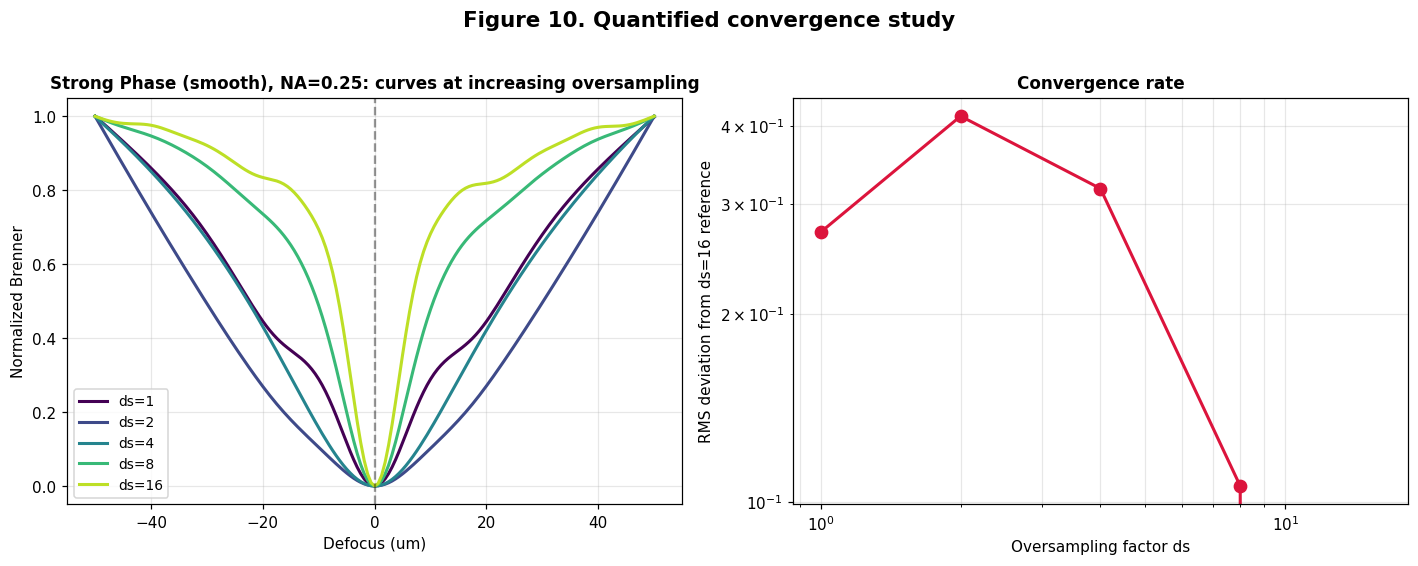

In [4]:
conv_NA = 0.25
conv_name = "Strong Phase (smooth)"
ds_list = [1, 2, 4, 8, 16]

curves_by_ds = {}
for ds_test in ds_list:
    N_hr_t = N_LR * ds_test
    objs_t = make_objects(N_hr_t)
    FX_t, FY_t = build_grid(N_LR, N_hr_t, EFF_PIXEL_UM)
    cy_t, cx_t = N_hr_t // 2, N_hr_t // 2
    ys_t, ye_t = cy_t - N_LR//2, cy_t + N_LR//2
    xs_t, xe_t = cx_t - N_LR//2, cx_t + N_LR//2

    pupil_t = (np.sqrt(FX_t**2 + FY_t**2) <= conv_NA / WAVELENGTH_UM).astype(float)
    radicand_t = np.maximum((1/WAVELENGTH_UM)**2 - FX_t**2 - FY_t**2, 0)
    kz_t = 2*np.pi*np.sqrt(radicand_t)

    O_fft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(objs_t[conv_name])))
    O_crop = O_fft[ys_t:ye_t, xs_t:xe_t]

    scores = []
    for z in Z_ARRAY_UM:
        pupil_z = pupil_t * np.exp(1j * z * kz_t)
        E_f = O_crop * pupil_z
        E_s = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_f)))
        scores.append(brenner_raw(np.abs(E_s)**2))
    scores = np.array(scores)
    curves_by_ds[ds_test] = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

reference = curves_by_ds[max(ds_list)]
rms_errors = []
for ds_test in ds_list:
    err = np.sqrt(np.mean((curves_by_ds[ds_test] - reference) ** 2))
    rms_errors.append(err)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ds_test, c in zip(ds_list, plt.cm.viridis(np.linspace(0, 0.9, len(ds_list)))):
    axes[0].plot(Z_ARRAY_UM, curves_by_ds[ds_test], color=c, lw=2, label=f"ds={ds_test}")
axes[0].axvline(0, color='k', ls='--', alpha=0.4)
axes[0].set_xlabel("Defocus (um)"); axes[0].set_ylabel("Normalized Brenner")
axes[0].set_title(f"{conv_name}, NA={conv_NA}: curves at increasing oversampling", fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].loglog(ds_list, rms_errors, 'o-', color='crimson', markersize=8, linewidth=2)
axes[1].set_xlabel("Oversampling factor ds"); axes[1].set_ylabel(f"RMS deviation from ds={max(ds_list)} reference")
axes[1].set_title("Convergence rate", fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3, which='both')

fig.suptitle("Figure 10. Quantified convergence study", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("figs/fig10_quantified_convergence.png", dpi=150, bbox_inches='tight')
plt.show()

print("RMS deviation from ds=16 reference, by oversampling factor:")
for ds_test, err in zip(ds_list, rms_errors):
    print(f"  ds={ds_test:<3} RMS error = {err:.5f}")
converged = rms_errors[-2] < 0.02
print(f"\nCurve at ds=8 within 2% RMS of ds=16 reference: {converged}")
print("If True, ds=4 (used throughout the main notebook) is under-converged and ds>=8 should be the")
print("production default; if the error is already small at ds=4, the original choice is defensible.")

## Experiment 3 — Autofocus location bias

For every object type and every NA, find *where* the extremum of the Brenner curve actually sits.
A robust autofocus method should locate z=0 (the true focal plane) regardless of NA. Systematic
deviation is a quantifiable failure mode, not just a qualitative "it looks off."

Maximum |focus error| across the NA sweep, by object type:
  Pure Amplitude            max |bias| = 0.00 um
  Weak Phase (smooth)       max |bias| = 0.00 um
  Strong Phase (smooth)     max |bias| = 0.00 um


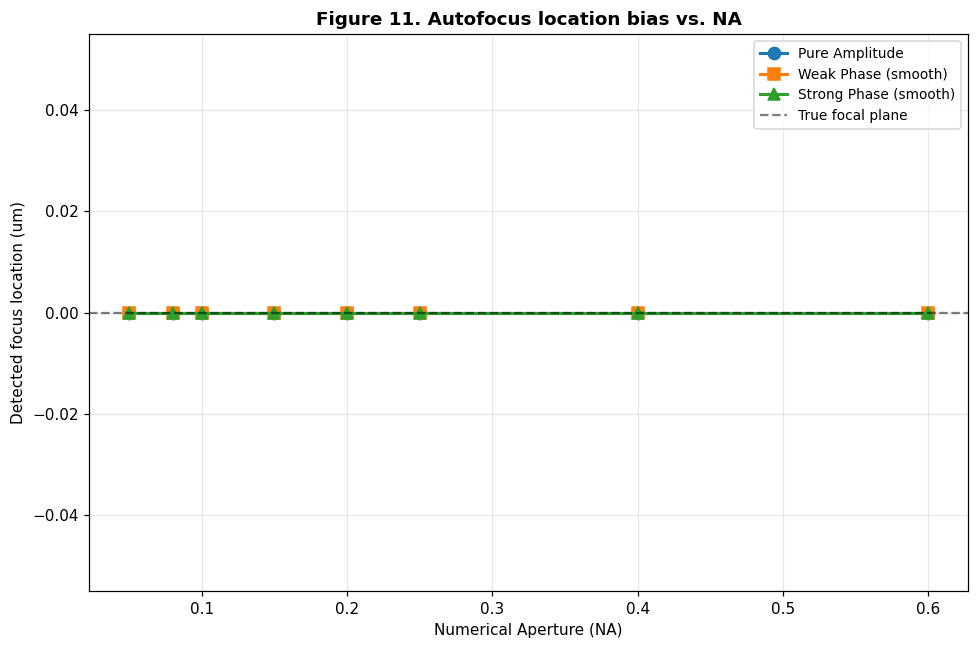

In [6]:
NA_LIST = [0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.40, 0.60]
bias_results = {}
for name in ["Pure Amplitude", "Weak Phase (smooth)", "Strong Phase (smooth)"]:
    O_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(objects_hr[name])))
    biases = []
    for NA in NA_LIST:
        stack = propagate_stack(O_fourier, NA)
        scores = np.array([brenner_raw(f) for f in stack])
        if name == "Pure Amplitude":
            z_hat = Z_ARRAY_UM[np.argmax(scores)]
        else:
            z_hat = Z_ARRAY_UM[np.argmin(scores)]
        biases.append(z_hat)
    bias_results[name] = biases

fig, ax = plt.subplots(figsize=(9, 6))
markers = {'Pure Amplitude': 'o', 'Weak Phase (smooth)': 's', 'Strong Phase (smooth)': '^'}
for name, biases in bias_results.items():
    ax.plot(NA_LIST, biases, marker=markers[name], markersize=8, lw=2, label=name)
ax.axhline(0, color='k', ls='--', alpha=0.5, label='True focal plane')
ax.set_xlabel("Numerical Aperture (NA)"); ax.set_ylabel("Detected focus location (um)")
ax.set_title("Figure 11. Autofocus location bias vs. NA", fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/fig11_autofocus_bias.png", dpi=150, bbox_inches='tight')
plt.show()

max_bias = {name: float(np.max(np.abs(b))) for name, b in bias_results.items()}
print("Maximum |focus error| across the NA sweep, by object type:")
for name, mb in max_bias.items():
    print(f"  {name:<25} max |bias| = {mb:.2f} um")

## Experiment 4 — Noise success-rate curve

Instead of one noisy realization, run repeated Poisson-noise trials at each photon budget and
report the fraction of trials where the detected extremum lands within one defocus step of the
true focal plane. This converts Figure 8 into an actual reliability curve.

Photon budget at which success rate first drops below 50%, by object type:
  Weak Phase (smooth)      : below 50% at <= 5000 photons
  Strong Phase (smooth)    : below 50% at <= 5000 photons


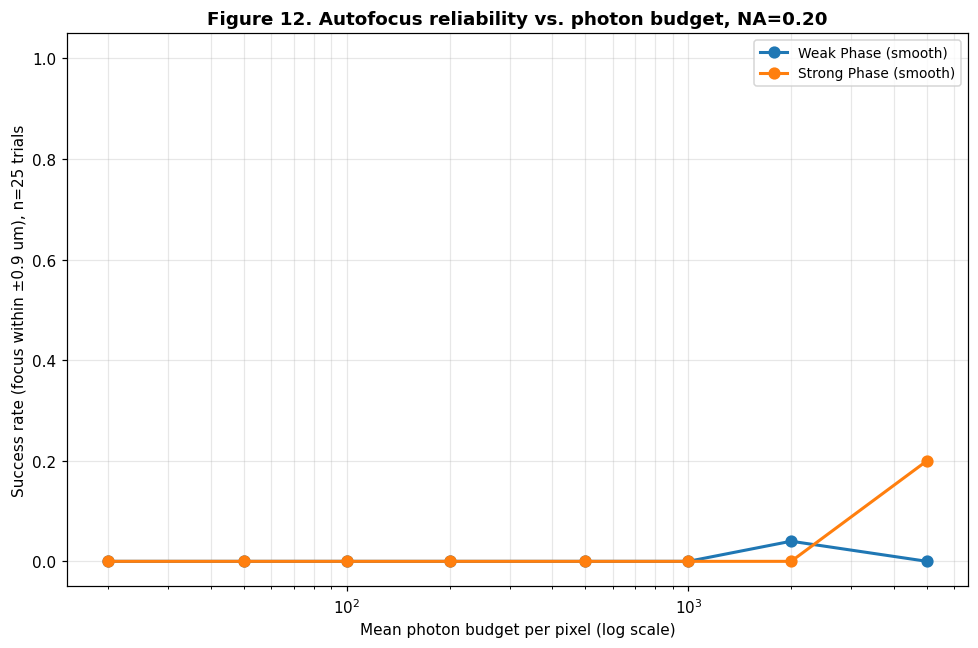

In [8]:
def add_shot_noise(intensity_frame, mean_photon_count, rng):
    scaled = intensity_frame / (intensity_frame.max() + 1e-12) * mean_photon_count
    return rng.poisson(np.clip(scaled, 0, None)).astype(float)

photon_budgets = [5000, 2000, 1000, 500, 200, 100, 50, 20]
n_trials = 25
tolerance_um = (Z_ARRAY_UM[1] - Z_ARRAY_UM[0]) * 1.5

success_curves = {}
for name in ["Weak Phase (smooth)", "Strong Phase (smooth)"]:
    O_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(objects_hr[name])))
    stack_clean = propagate_stack(O_fourier, 0.20)
    rates = []
    for budget in photon_budgets:
        rng = np.random.default_rng(42)
        hits = 0
        for trial in range(n_trials):
            noisy_stack = np.array([add_shot_noise(f, budget, rng) for f in stack_clean])
            scores = np.array([brenner_raw(f) for f in noisy_stack])
            z_hat = Z_ARRAY_UM[np.argmin(scores)]
            if abs(z_hat - 0.0) <= tolerance_um:
                hits += 1
        rates.append(hits / n_trials)
    success_curves[name] = rates

fig, ax = plt.subplots(figsize=(9, 6))
for name, rates in success_curves.items():
    ax.plot(photon_budgets, rates, 'o-', markersize=7, lw=2, label=name)
ax.set_xscale('log')
ax.set_xlabel("Mean photon budget per pixel (log scale)")
ax.set_ylabel(f"Success rate (focus within ±{tolerance_um:.1f} um), n={n_trials} trials")
ax.set_title("Figure 12. Autofocus reliability vs. photon budget, NA=0.20", fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("figs/fig12_noise_success_rate.png", dpi=150, bbox_inches='tight')
plt.show()

print("Photon budget at which success rate first drops below 50%, by object type:")
for name, rates in success_curves.items():
    below = [b for b, r in zip(photon_budgets, rates) if r < 0.5]
    print(f"  {name:<25}: {'below 50% at <= ' + str(max(below)) + ' photons' if below else 'never drops below 50% in tested range'}")

## Consolidated numeric summary for the report

In [10]:
extended_summary = {
    "critical_NA": {
        "weak_phase": crit_weak,
        "strong_phase": crit_strong,
        "NA_where_optical_cutoff_equals_camera_nyquist": CAMERA_NYQUIST * WAVELENGTH_UM,
    },
    "convergence": {
        "ds_list": ds_list,
        "rms_error_vs_ds16": rms_errors,
    },
    "autofocus_bias_um": bias_results,
    "max_abs_bias_um": max_bias,
    "noise_success_rate": {
        "photon_budgets": photon_budgets,
        "rates": success_curves,
        "tolerance_um": tolerance_um,
    },
}
with open("figs/extended_summary_results.json", "w") as f:
    json.dump(extended_summary, f, indent=2, default=float)
print("Saved figs/extended_summary_results.json")

Saved figs/extended_summary_results.json
